<a href="https://colab.research.google.com/github/farahshafiyah01-max/Financial-Modelling-Analytics/blob/main/Sime_Darby_Plantation_5285_KL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1: Install required packages
!pip install yfinance pandas ta scikit-learn shap matplotlib seaborn plotly

print("Packages installed!\n")

Packages installed!



In [ ]:
#2: Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Libraries imported!\n")

Libraries imported!



In [ ]:
#3: Download data (EXACT period: 2021-01-01 to 2025-12-31)
start, end = '2021-01-01', '2025-12-31'
plantation = yf.download('5285.KL', start=start, end=end)
klci = yf.download('^KLSE', start=start, end=end)

data = plantation.copy()

# Flatten multi-level columns if they exist
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

data['KLCI_Close'] = klci['Close']
data.dropna(inplace=True)

print(f"Sime Darby Plantation Berhad (5285.KL) data: {data.shape[0]} days")
print("Sample data:")
print(data[['Open', 'High', 'Low', 'Close', 'Volume', 'KLCI_Close']].head())

/tmp/ipykernel_734/1060804198.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  plantation = yf.download('5285.KL', start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_734/1060804198.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  klci = yf.download('^KLSE', start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Sime Darby Plantation Berhad (5285.KL) data: 1222 days
Sample data:
Price           Open      High       Low     Close   Volume   KLCI_Close
Date                                                                    
2021-01-04  4.108105  4.140970  4.083456  4.099888  1774300  1602.569946
2021-01-05  4.108104  4.165618  4.075239  4.140969  2115200  1608.349976
2021-01-06  4.140970  4.149186  4.083456  4.099888  2201100  1591.969971
2021-01-07  4.108104  4.272428  4.091672  4.231348  3790600  1602.949951
2021-01-08  4.157401  4.264212  4.140969  4.247779  4847000  1633.189941


In [ ]:
#4: Create EXACTLY 5 technical indicators + market benchmark
data['MA5'] = ta.trend.sma_indicator(data['Close'], window=5)
data['MA20'] = ta.trend.sma_indicator(data['Close'], window=20)
data['RSI'] = ta.momentum.rsi(data['Close'])
data['MACD'] = ta.trend.MACD(data['Close']).macd()
data['Volatility'] = data['Close'].rolling(20).std()
data['KLCI_Return'] = data['KLCI_Close'].pct_change()

print("Created 5 technical indicators + KLCI_Return:")
print(data[['MA5', 'MA20', 'RSI', 'MACD', 'Volatility', 'KLCI_Return']].tail())

Created 5 technical indicators + KLCI_Return:
Price            MA5      MA20        RSI      MACD  Volatility  KLCI_Return
Date                                                                        
2025-12-23  5.434781  5.271030  63.320863  0.058739    0.113331     0.003201
2025-12-24  5.468220  5.286766  67.060101  0.067858    0.125927     0.000996
2025-12-26  5.505593  5.308403  70.318726  0.079720    0.139994    -0.000721
2025-12-29  5.517395  5.330531  67.248248  0.085752    0.144226     0.002319
2025-12-30  5.560669  5.355610  71.297327  0.096562    0.155028     0.002106


In [ ]:
#5: Target variable - Next-day return
data['Next_Return'] = data['Close'].pct_change().shift(-1)
data.dropna(inplace=True)

print("Target: Next-day return")
print(data['Next_Return'].describe())

Target: Next-day return
count    1196.000000
mean        0.000442
std         0.018497
min        -0.100939
25%        -0.008944
50%         0.000000
75%         0.009055
max         0.147541
Name: Next_Return, dtype: float64


In [ ]:
#6: Features and data cleaning
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'RSI',
            'MACD', 'Volatility', 'KLCI_Return']

X = data[features].dropna()
y = data.loc[X.index, 'Next_Return'].dropna()
X = X.loc[y.index]

print(f"Clean dataset: {X.shape[0]} rows, {len(features)} features")
print("Features:", features)

Clean dataset: 1196 rows, 11 features
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'RSI', 'MACD', 'Volatility', 'KLCI_Return']


In [ ]:
#7: 80/20 time-based split
split = int(0.8 * len(X))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {X_train.shape} ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test:  {X_test.shape} ({X_test.index[0].date()} to {X_test.index[-1].date()})")


Train: (956, 11) (2021-02-10 to 2025-01-03)
Test:  (240, 11) (2025-01-06 to 2025-12-29)


In [ ]:
#8: ONE tree-based model - Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Performance metrics
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nRandom Forest Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")


Random Forest Performance:
MAE: 0.0102
RMSE: 0.0139
R2: -0.1377


/tmp/ipykernel_734/1382771262.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.tail(8), y='Feature', x='Importance', ax=axes[1,1], palette='viridis')


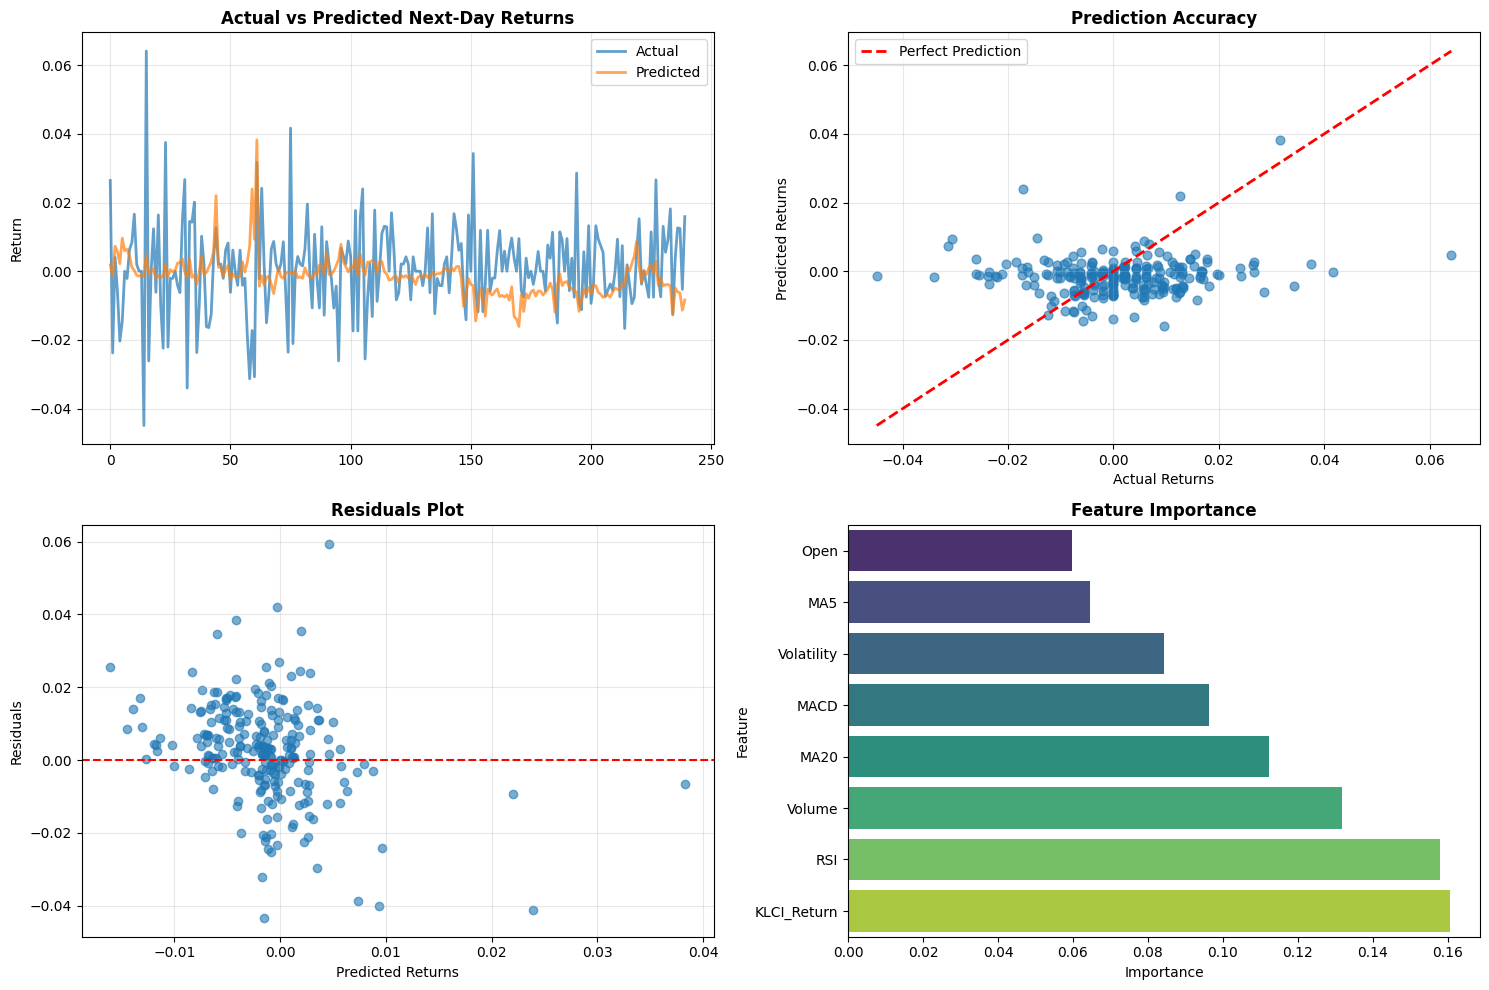

In [ ]:
#9: Performance visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Actual vs Predicted
axes[0,0].plot(y_test.values, label='Actual', alpha=0.7, linewidth=2)
axes[0,0].plot(y_pred, label='Predicted', alpha=0.7, linewidth=2)
axes[0,0].set_title('Actual vs Predicted Next-Day Returns', fontweight='bold')
axes[0,0].set_ylabel('Return')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Scatter plot
axes[0,1].scatter(y_test, y_pred, alpha=0.6, s=40)
perfect_line = [y_test.min(), y_test.max()]
axes[0,1].plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect Prediction')
axes[0,1].set_xlabel('Actual Returns')
axes[0,1].set_ylabel('Predicted Returns')
axes[0,1].set_title('Prediction Accuracy', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Residuals
residuals = y_test - y_pred
axes[1,0].scatter(y_pred, residuals, alpha=0.6)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Returns')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Residuals Plot', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 4. Feature importance (built-in)
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=True)
sns.barplot(data=feat_df.tail(8), y='Feature', x='Importance', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Feature Importance', fontweight='bold')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

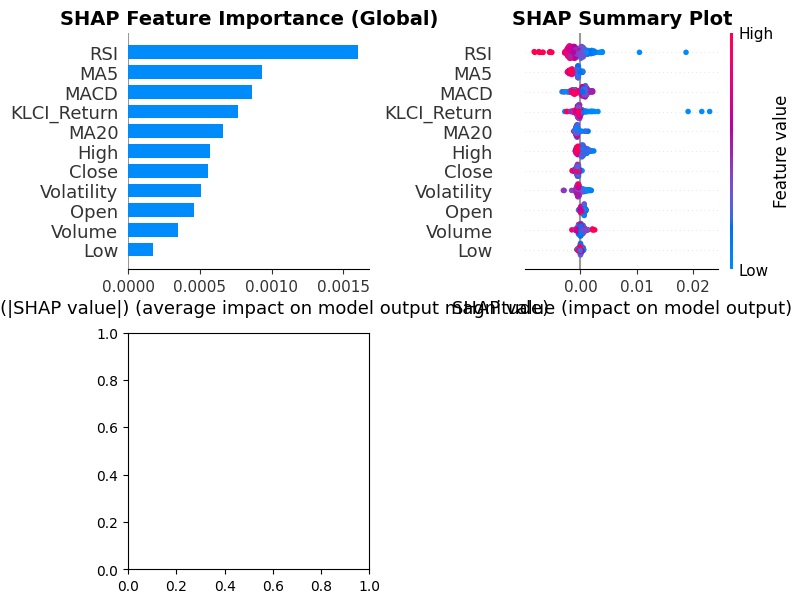

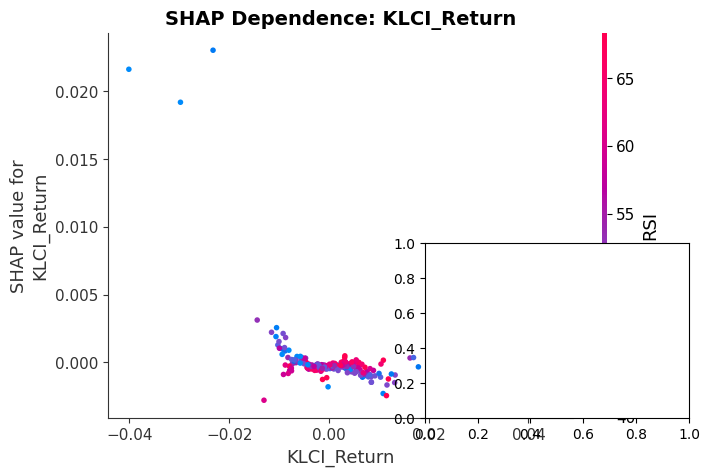

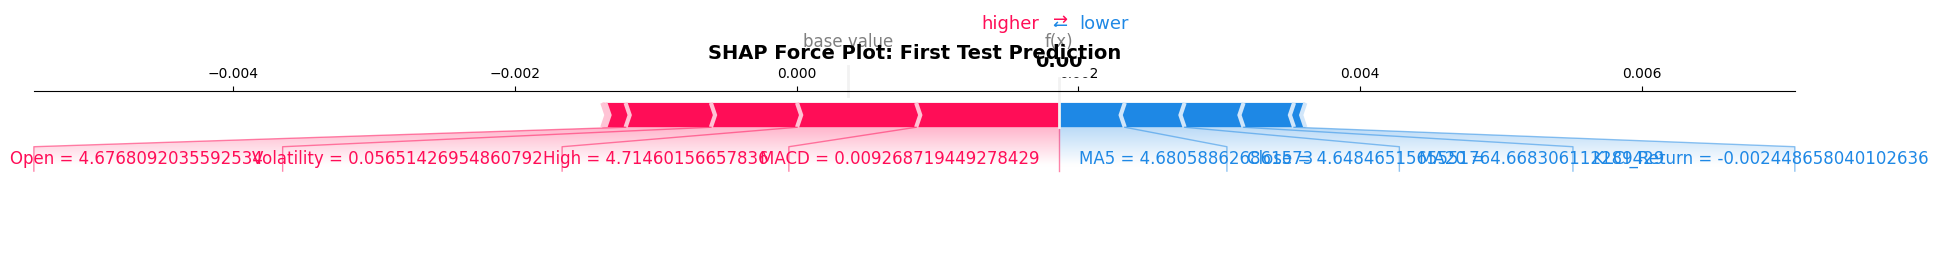

In [ ]:
#10: XAI - SHAP analysis
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(15, 12))

# SHAP Summary Plot
plt.subplot(2, 2, 1)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=11, show=False)
plt.title('SHAP Feature Importance (Global)', fontweight='bold', fontsize=14)

# SHAP Summary Scatter
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X_test, max_display=11, show=False)
plt.title('SHAP Summary Plot', fontweight='bold', fontsize=14)

# SHAP Dependence (Top feature)
top_feature = feat_df.iloc[-1]['Feature']
plt.subplot(2, 2, 3)
shap.dependence_plot(top_feature, shap_values, X_test, show=False)
plt.title(f'SHAP Dependence: {top_feature}', fontweight='bold', fontsize=14)

# Single prediction force plot
plt.subplot(2, 2, 4)
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], matplotlib=True, show=False)
plt.title('SHAP Force Plot: First Test Prediction', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
#11: Export deliverables
final_data = X.copy()
final_data['Next_Return'] = y
final_data['Predicted_Return'] = rf_model.predict(X)
final_data['Actual_Return'] = y
final_data.to_csv('sime_darby_plantation_5285_complete.csv')

results_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})
results_summary.to_csv('performance_metrics.csv', index=False)

print("\nASSIGNMENT REQUIREMENTS FULFILLED:")
print("Company: Sime Darby Plantation Berhad (5285.KL)")
print("Data period: 2021-01-01 to 2025-12-31")
print("5 technical indicators + KLCI_Return")
print("Target: Next-day return")
print("80/20 time-based split")
print("ONE tree-based model: Random Forest")
print("Regression metrics: MAE, RMSE, R2")
print("ONE XAI method: SHAP values")
print("\nFILES SAVED:")
print("sime_darby_plantation_5285_complete.csv")
print("performance_metrics.csv")


ASSIGNMENT REQUIREMENTS FULFILLED:
Company: Sime Darby Plantation Berhad (5285.KL)
Data period: 2021-01-01 to 2025-12-31
5 technical indicators + KLCI_Return
Target: Next-day return
80/20 time-based split
ONE tree-based model: Random Forest
Regression metrics: MAE, RMSE, R2
ONE XAI method: SHAP values

FILES SAVED:
sime_darby_plantation_5285_complete.csv
performance_metrics.csv
